In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Flatten,Dense,Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import random
import matplotlib.image as mpimg
import kagglehub

In [2]:
#Set random seeds for reproducibility
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

print("Libraries imported sucessfully. ")

# Download Dataset via Kaggle Hub API & Set Paths
print("Downloading/fetching dataset from kaggle...")
dataset_path=kagglehub.dataset_download("puneet6060/intel-image-classification")
print(f"Dataset stored at :{dataset_path}")


Libraries imported sucessfully. 
Downloading/fetching dataset from kaggle...
Using Colab cache for faster access to the 'intel-image-classification' dataset.
Dataset stored at :/kaggle/input/intel-image-classification


In [3]:
#Define directory paths based on the downloaded kaggle structure

train_dir=os.path.join(dataset_path,"seg_train","seg_train")
test_dir=os.path.join(dataset_path,"seg_test","seg_test")

#Define global configuration parameters
IMG_SIZE=(150,150)
BATCH_SIZE=32



# Data Loading, Preprocessing, and Augmentation

In [4]:
print("\n---Loading Training Set---")
train_ds=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,             #Reserves 20% for validation
    subset="training",
    seed=42,                          #Fixed seed ensures train and validation sets do not overlap
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"          #Categorical crossentropy label
)


---Loading Training Set---
Found 14034 files belonging to 6 classes.
Using 11228 files for training.


In [5]:
print("\n---Loading Validation Set ---")
val_ds=tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)


---Loading Validation Set ---
Found 14034 files belonging to 6 classes.
Using 2806 files for validation.


In [6]:
print("\n Loading Test Set...")
test_ds=tf.keras.utils.image_dataset_from_directory(
    test_dir,
    shuffle=False,            #Keep False to ensure true labels align with predictions
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical"
)



 Loading Test Set...
Found 3000 files belonging to 6 classes.


In [7]:
#Extract class names from the dataset
class_name= train_ds.class_names
print(f"\n Class Labels ({len(class_name)} total):{class_name}")


 Class Labels (6 total):['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


In [8]:
#Define Data Augmentation and Normalization Sequential Layers
#Integrated directly into model  input pipeline

data_augmentation=tf.keras.Sequential([
    tf.keras.layers.Rescaling(1. /255),                 #Normalize pixels from[0, 255] to [0,1]
    tf.keras.layers.RandomFlip("horizontal"),           #Horrizontal flips
    tf.keras.layers.RandomRotation(0.1),                #Rotation upto 10%
    tf.keras.layers.RandomZoom(0.1),                    #Zoom upto 10%
], name="data_augmentation")


#Seprate normalization layer for validation/testing (no augmentation)
rescale_layer=tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255)
], name="rescale_layer")


#Optimize input pipeline performance using caching and prefetching

train_ds=train_ds.map(lambda x,y: (data_augmentation(x, training=True),y), num_parallel_calls=tf.data.AUTOTUNE)
train_ds=train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

val_ds=val_ds.map(lambda x,y: (rescale_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)
val_ds=val_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

#Keep raw test dataset mapped to rescale layer for evaluation later
test_ds_scaled=test_ds.map(lambda x,y: (rescale_layer(x), y), num_parallel_calls=tf.data.AUTOTUNE)

# CNN Model Architecture Development

In [9]:
model=Sequential([
    # Input Specification
    tf.keras.layers.Input(shape=(150,150,3)),

    #Convolution Block 1
    Conv2D(32, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    #Convolution Block 2
    Conv2D(64, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    #Convolution Block 3
    Conv2D(128, (3,3), activation="relu"),
    MaxPooling2D((2,2)),

    #Fully Connected Dense Classifier
    Flatten(),
    Dense(512,activation='relu'),
    Dropout(0.5),                  #Regularization to prevent overfitting
    Dense(len(class_name),activation='softmax')   #Output layer for 6 classes
],name="Intel_CNN_Model")

#Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "Intel_CNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 148, 148, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 74, 74, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 72, 72, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 36, 36, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 34, 34, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 17, 17, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36992)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    18,940,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         3,078 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,036,742 (72.62 MB)

 Trainable params: 19,036,742 (72.62 MB)

 Non-trainable params: 0 (0.00 B)

# Train the CNN Model

In [10]:
#Callbacks for optimal training

callbacks =[
    EarlyStopping(monitor='val_loss',patience=5,restore_best_weights=True),
    ModelCheckpoint('intel_cnn_best.h5',monitor='val_accuracy',save_best_only=True)
]

EPOCHS = 10

print("\n ---Starting Training---")
history =model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


 ---Starting Training---
Epoch 1/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4887 - loss: 1.3442

351/351 ━━━━━━━━━━━━━━━━━━━━ 787s 2s/step - accuracy: 0.5742 - loss: 1.0996 - val_accuracy: 0.6657 - val_loss: 0.9101
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6676 - loss: 0.8901

351/351 ━━━━━━━━━━━━━━━━━━━━ 820s 2s/step - accuracy: 0.6847 - loss: 0.8450 - val_accuracy: 0.6914 - val_loss: 0.8193
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7227 - loss: 0.7465

351/351 ━━━━━━━━━━━━━━━━━━━━ 655s 2s/step - accuracy: 0.7441 - loss: 0.7011 - val_accuracy: 0.7316 - val_loss: 0.7414
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7801 - loss: 0.6180

351/351 ━━━━━━━━━━━━━━━━━━━━ 645s 2s/step - accuracy: 0.7938 - loss: 0.5777 - val_accuracy: 0.7441 - val_loss: 0.7869
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 617s 2s/step - accuracy: 0.8321 - loss: 0.4589 - val_accuracy: 0.7313 - val_loss: 0.8763
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 614s 2s/step - accuracy: 0.8681 - loss: 0.3625 - val_accuracy: 0.7074 - val_loss: 1.1707
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8918 - loss: 0.3127

351/351 ━━━━━━━━━━━━━━━━━━━━ 632s 2s/step - accuracy: 0.9021 - loss: 0.2834 - val_accuracy: 0.7452 - val_loss: 1.0466
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 626s 2s/step - accuracy: 0.9246 - loss: 0.2135 - val_accuracy: 0.7259 - val_loss: 1.4339


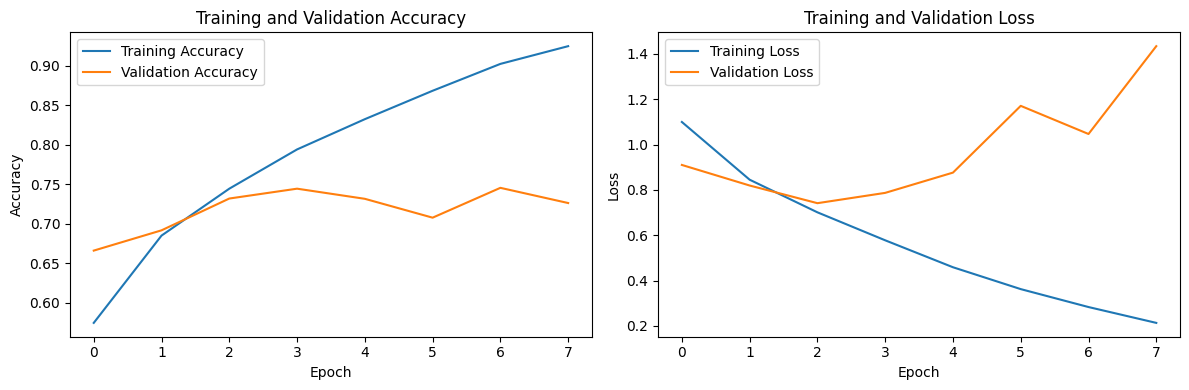

In [11]:
#Plot Training and Validation Loss/Accuracy Curves

plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'],label='Training Accuracy')
plt.plot(history.history['val_accuracy'],label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'],label='Training Loss')
plt.plot(history.history['val_loss'],label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

# Model Evaluation and  Performance Metrics


 --- Evaluation Model on Test Data ---
94/94 ━━━━━━━━━━━━━━━━━━━━ 52s 557ms/step - accuracy: 0.7363 - loss: 0.7511
Test Loss: 0.75
Test Accuracy: 0.74

---Classification Report---
              precision    recall  f1-score   support

   buildings       0.66      0.72      0.69       437
      forest       0.91      0.89      0.90       474
     glacier       0.86      0.53      0.66       553
    mountain       0.73      0.65      0.68       525
         sea       0.60      0.84      0.70       510
      street       0.77      0.81      0.79       501

    accuracy                           0.74      3000
   macro avg       0.75      0.74      0.74      3000
weighted avg       0.75      0.74      0.73      3000



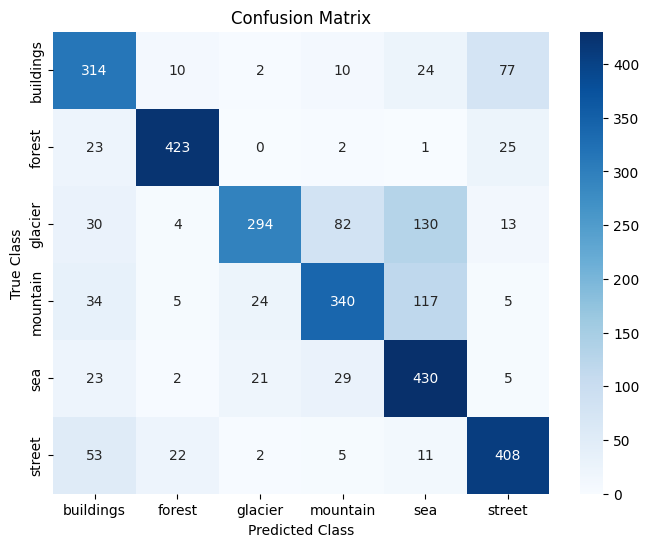

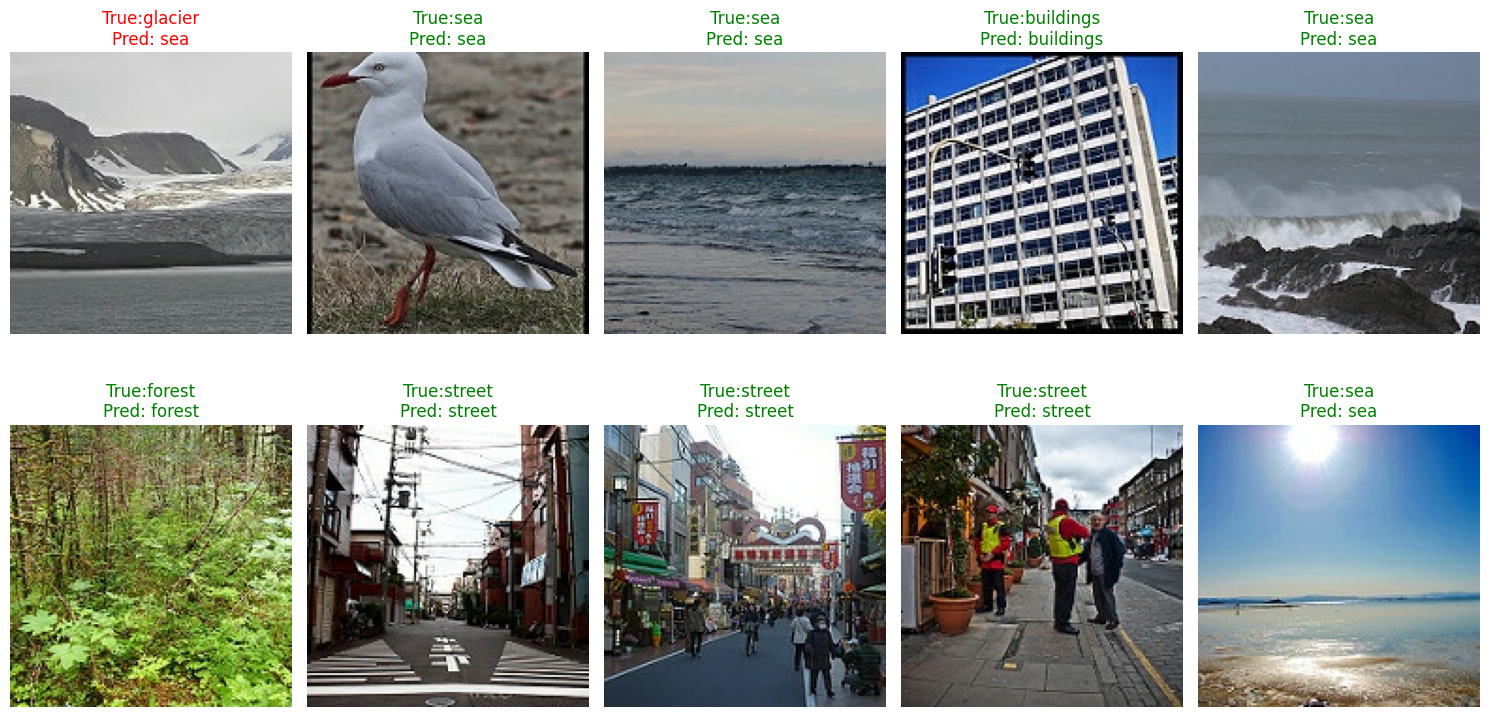

In [16]:
print("\n --- Evaluation Model on Test Data ---")
test_loss, test_accuracy=model.evaluate(test_ds_scaled)
print(f"Test Loss: {test_loss:.2f}")
print(f"Test Accuracy: {test_accuracy:.2f}")

#Generate  prediction across the test set
#Extract  true labels and predictions
y_true= []
y_pred_probs =[]

for images, labels in test_ds_scaled:
    preds= model.predict(images, verbose=0)
    y_pred_probs.extend(preds)
    y_true.extend(np.argmax(labels.numpy(),axis=1))

y_pred=np.argmax(y_pred_probs,axis=1)

y_true=np.array(y_true)

#Print Classification Report (Precision,Recall, F1-Score per class)
print("\n---Classification Report---")
print(classification_report(y_true,y_pred,target_names=class_name))


#Plot Confusion Matrix
cm=confusion_matrix(y_true,y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',xticklabels=class_name,yticklabels=class_name)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.show()


#Visualize Random Test Predictions

#Gather raw unscaled  test images and labels for visualization
test_images=[]
for images, labels in test_ds:
    test_images.extend(images.numpy())

#Select 10 random indices

random_indices=random.sample(range(len(test_images)),10)

plt.figure(figsize=(15,8))
for i,idx in enumerate(random_indices):
    img=test_images[idx].astype("uint8") #Cast back to uint8 for rendering
    true_label=class_name[y_true[idx]]
    pred_label=class_name[y_pred[idx]]

    plt.subplot(2,5,i+1)
    plt.imshow(img)
    plt.axis('off')


    #Title green if correct , red if incorrect

    color='green' if true_label==pred_label else 'red'
    plt.title(f"True:{true_label}\nPred: {pred_label}",color=color)

plt.tight_layout()
plt.show()